## Mid-Term Load Forecast EDA (Weather Zones, 2022 Feb - 2025 Dec)

**Source:** `data/02_processed/load/mid_term_load_forecast_20220201_20251201.parquet`
- Raw Source: `data/01_raw/ercot/Load Forecast/Mid_Term_Load_Forecast_Metrics_*.xlsx`  
- Parsed by: `src/extraction/parse_mid_term_load_forecast_parquet.py`  

**Schemas** 
- 8 ERCOT weather zones + system total (Coast, East, Far West, North Central, North, South Central, South, West, ERCOT)
- Actual load + Forecast load + forecast Error

**Output:** `data/02_processed/load/forecast WZ/..`
- error by weather zone: `load_fcst_error_*.csv`
- load by weather zone: `load_actual_by_weather_zone_*.csv`
- ercot total: `load_ercot_error_*.csv`

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PARQUET = Path("../../01_data/2_cleaned/load/forecast/mid_term_load_forecast_20220201_20251201.parquet")
OUT_DIR = Path("../../01_data/2_cleaned/load/forecast")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
con = duckdb.connect()
# validate time range and column names

column_schema = con.execute(f"""
    DESCRIBE SELECT * FROM read_parquet('{PARQUET}')
""").df()
print('=== Schema ===')
print(column_schema.to_string(index=False))

time_range = con.execute(f"""
    SELECT 
        MIN(datetime) AS min_date
        ,MAX(datetime) AS max_date
    FROM read_parquet('{PARQUET}')
""").fetchone()
print('\n=== Time Range ===')
print(f'{time_range[0]} to {time_range[1]}')

=== Schema ===
     column_name column_type null  key default extra
        datetime   TIMESTAMP  YES None    None  None
    actual_Coast      DOUBLE  YES None    None  None
  forecast_Coast      DOUBLE  YES None    None  None
     error_Coast      DOUBLE  YES None    None  None
     actual_East      DOUBLE  YES None    None  None
   forecast_East      DOUBLE  YES None    None  None
      error_East      DOUBLE  YES None    None  None
  actual_FarWest      DOUBLE  YES None    None  None
forecast_FarWest      DOUBLE  YES None    None  None
   error_FarWest      DOUBLE  YES None    None  None
    actual_NCent      DOUBLE  YES None    None  None
  forecast_NCent      DOUBLE  YES None    None  None
     error_NCent      DOUBLE  YES None    None  None
    actual_North      DOUBLE  YES None    None  None
  forecast_North      DOUBLE  YES None    None  None
     error_North      DOUBLE  YES None    None  None
    actual_SCent      DOUBLE  YES None    None  None
  forecast_SCent      DOUBLE  Y

In [4]:
# load data
df = pd.read_parquet(PARQUET)
df.head(5)

,datetime,actual_Coast,forecast_Coast,error_Coast,actual_East,forecast_East,error_East,actual_FarWest,forecast_FarWest,error_FarWest,...,error_SCent,actual_South,forecast_South,error_South,actual_West,forecast_West,error_West,actual_ERCOT,forecast_ERCOT,error_ERCOT
0,2022-02-01 01:00:00,9810.580078,9466.780273,-343.799805,1405.159668,1391.140015,-14.019653,4122.378906,4361.100098,238.721191,...,12.415527,2525.002197,2589.600098,64.597900,1405.745727,990.882019,-414.863708,35709.832031,35148.0,-561.832031
1,2022-02-01 02:00:00,9549.062500,9225.679688,-323.382812,1361.329712,1340.290039,-21.039673,4171.669922,4309.160156,137.490234,...,-53.059082,2447.211426,2480.820068,33.608643,1348.366699,963.482971,-384.883728,34733.136719,34054.0,-679.136719
2,2022-02-01 03:00:00,9508.433594,9106.030273,-402.403320,1381.217285,1308.949951,-72.267334,4177.934570,4316.029785,138.095215,...,-128.201660,2406.486328,2432.459961,25.973633,1368.300293,927.721985,-440.578308,34448.484375,33502.0,-946.484375
3,2022-02-01 04:00:00,9494.667969,9140.269531,-354.398438,1331.285278,1312.030029,-19.255249,4151.956055,4369.890137,217.934082,...,-143.353027,2397.387451,2432.290039,34.902588,1398.666626,940.999023,-457.667603,34471.617188,33634.0,-837.617188
4,2022-02-01 05:00:00,9668.629883,9378.639648,-289.990234,1355.795532,1366.189941,10.394409,4164.668945,4367.990234,203.321289,...,-100.062500,2441.904053,2496.760010,54.855957,1377.646240,979.609985,-398.036255,35127.335938,34556.0,-571.335938


In [8]:
# EXPORT hourly data
df_ercot = df[['datetime', 'actual_ERCOT', 'error_ERCOT']]
df_ercot.to_csv(OUT_DIR/'Hourly ERCOT system load and prediction 20220201 20251201.csv', index=False)

In [4]:
# ── Null count ─────────────────────────────────────────────────────────
df_missing = df[df.isna().any(axis=1)]
df_missing['month'] = df_missing['datetime'].dt.strftime('%Y-%m')
print('=== Missing rows by month ===')
df_missing.groupby('month').count().reset_index()

=== Missing rows by month ===


,month,datetime,actual_Coast,forecast_Coast,error_Coast,actual_East,forecast_East,error_East,actual_FarWest,forecast_FarWest,...,error_SCent,actual_South,forecast_South,error_South,actual_West,forecast_West,error_West,actual_ERCOT,forecast_ERCOT,error_ERCOT
0,2022-03,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,23,23,23
1,2022-04,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
2,2022-05,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2022-06,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2023-02,1,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2023-03,22,0,0,0,22,22,22,22,22,...,22,22,22,22,22,22,22,0,0,0
6,2023-04,1,0,0,0,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,0
7,2023-05,25,25,25,25,1,1,1,1,1,...,1,1,1,1,1,1,1,23,23,23
8,2023-06,3,3,3,3,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
9,2023-11,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,0


In [5]:
# - duplicate dates --
df['datetime'].duplicated().sum()

np.int64(103)

In [6]:
# ── Summary stats ─────────────────────────────────────────────────────────
error_cols = [c for c in df.columns if c.startswith("error")]
df[error_cols].describe().round(1)

,error_Coast,error_East,error_FarWest,error_NCent,error_North,error_SCent,error_South,error_West,error_ERCOT
count,33603.0,33601.0,33600.0,33624.0,33600.0,33600.0,33600.0,33600.0,33622.0
mean,-3.4,18.9,-52.3,127.9,-11.3,17.6,-10.7,6.6,95.8
std,740.6,169.5,319.8,863.5,157.0,472.0,236.5,162.2,1741.5
min,-4234.2,-1842.5,-3475.7,-5283.8,-872.7,-4047.5,-1518.7,-1100.6,-13370.5
25%,-419.2,-62.1,-225.3,-369.4,-95.0,-260.1,-143.7,-93.5,-926.9
50%,-50.8,11.1,-63.8,55.6,-18.1,-1.2,-23.3,7.2,-14.6
75%,333.0,88.0,109.2,548.2,59.0,265.0,104.2,105.8,981.7
max,10314.1,2369.1,1919.8,7046.4,1590.7,3589.8,3191.6,963.6,13228.6


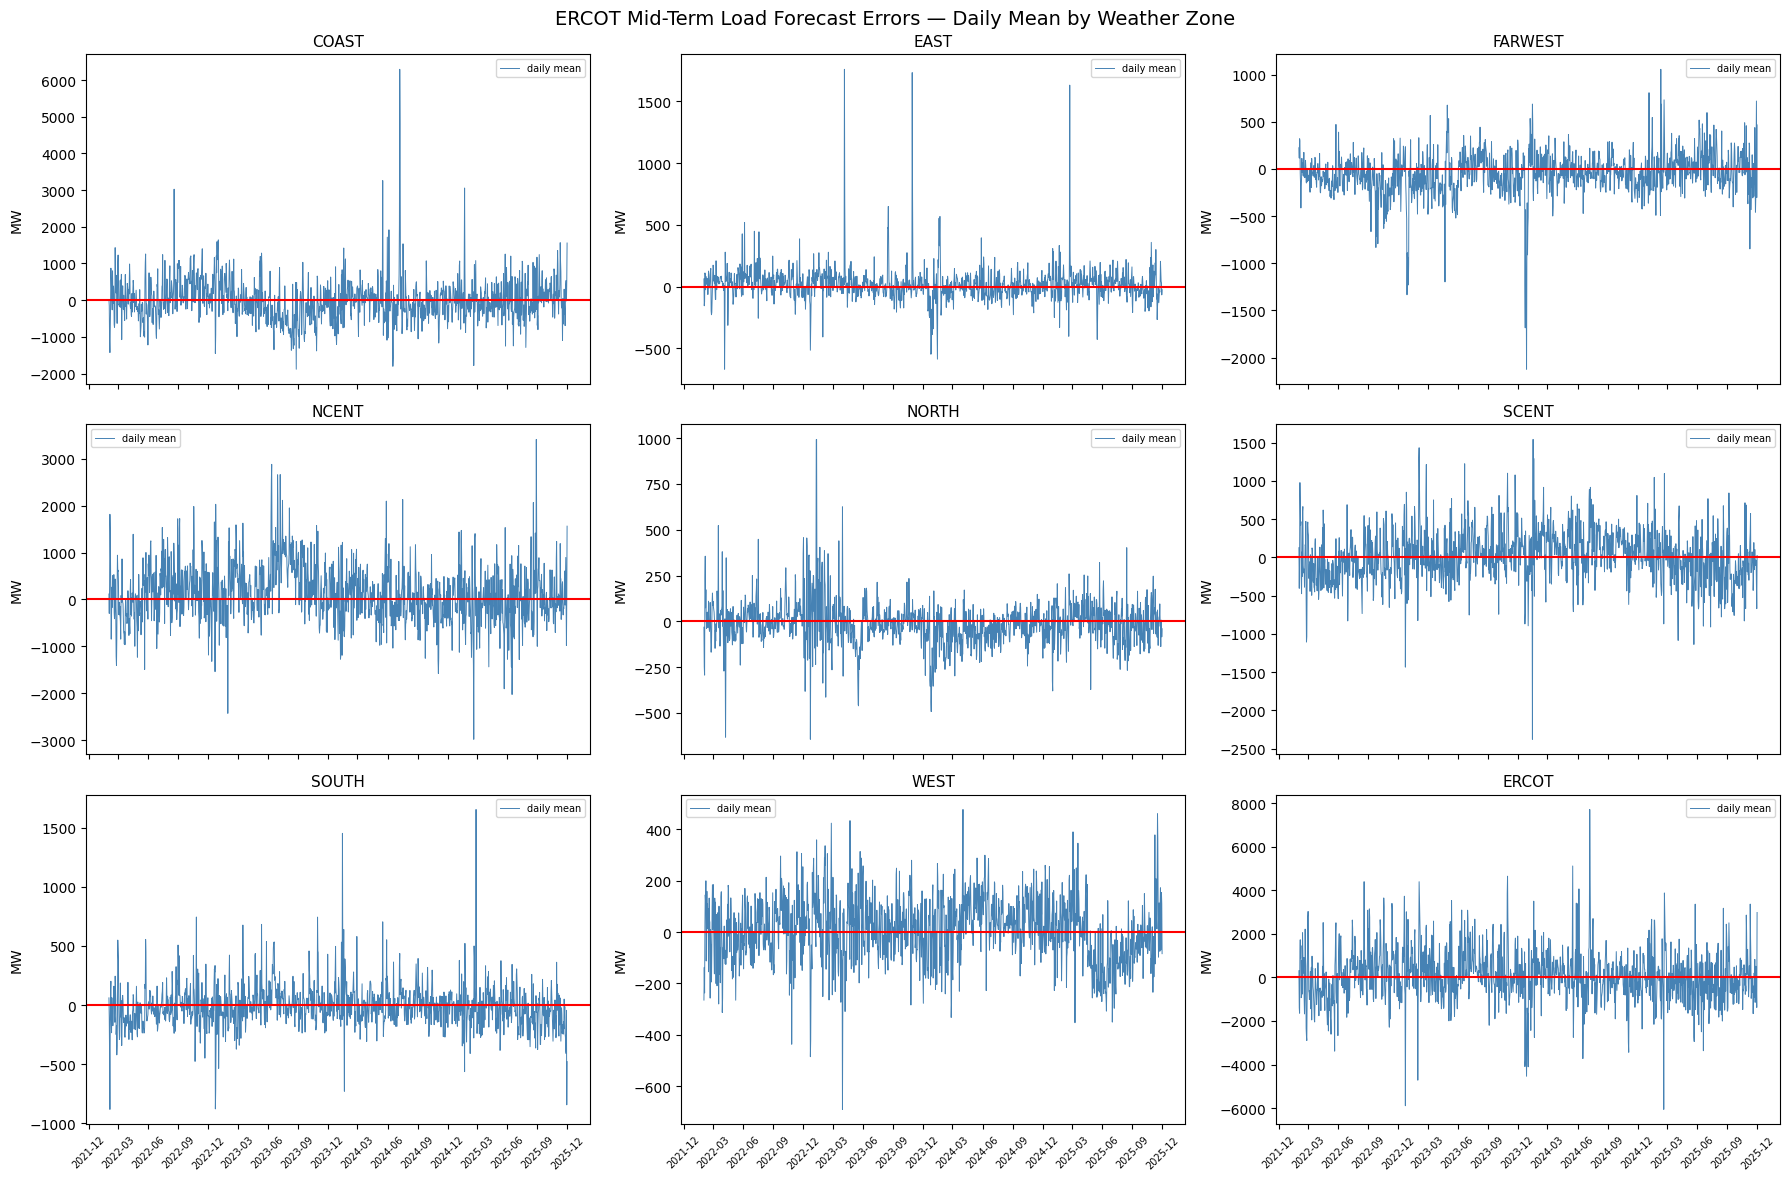

In [7]:
# ── 5. Daily mean time series — all weather zones ────────────────────────────
df["date"] = pd.to_datetime(df["datetime"]).dt.date
daily = df.groupby("date")[error_cols].mean()

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for ax, col in zip(axes, error_cols):
    zone = col.replace("error_", "").upper()
    ax.plot(daily.index, daily[col], lw=0.7, color="steelblue", label="daily mean")
    ax.axhline(0, color='red')
    ax.set_title(zone, fontsize=11)
    ax.set_ylabel("MW")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle("ERCOT Mid-Term Load Forecast Errors — Daily Mean by Weather Zone", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR/f'forecast_error_weather_zone_20220201_20251201.png')
plt.show()

In [8]:
# ── 7. Validation: sum(8 zones) vs error_ercot ────────────────────────────
zone8 = [c for c in error_cols if c != "error_ERCOT"]
df_val = df.dropna(subset=zone8 + ["error_ERCOT"]).copy()
df_val["zone_sum"] = df_val[zone8].sum(axis=1)
df_val["diff"] = (df_val["zone_sum"] - df_val["error_ERCOT"]).abs()

print(f"Rows with all 8 zones + ERCOT total non-null: {len(df_val)}")
print(f"Max |sum(zones) - ercot_total| : {df_val['diff'].max():.2f} MW")
print(f"Mean |diff|                    : {df_val['diff'].mean():.4f} MW")

Rows with all 8 zones + ERCOT total non-null: 33573
Max |sum(zones) - ercot_total| : 1042.72 MW
Mean |diff|                    : 13.9531 MW


In [11]:
# ── 8. export ───────────────────────────────

# export all error
df_error = df[['datetime'] + error_cols]
df_error.to_csv(OUT_DIR/f'load_fcst_error_20220201_20251201.csv', index=False)

# all actual load
forecast_cols = [c for c in df.columns if c.startswith('actual_')]
df_load = df[['datetime'] + forecast_cols] 
df_load.to_csv(OUT_DIR/f'load_actual_by_weather_zone_20220201_20251201.csv', index=False)

# ercot only
ercot_cols = [c for c in df.columns if c.endswith('ERCOT')]
df_ercot = df[['datetime', 'actual_ERCOT', 'error_ERCOT']]
df_ercot.to_csv(OUT_DIR/f'load_ercot_error_20220201_20251201.csv', index=False)